# Model Training

Notebook placeholder for model training experiments.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers , models
import matplotlib.pyplot as plt

In [3]:
model = models.Sequential([
    layers.Conv2D(32,(3,3) , activation="relu" , input_shape = (224,224,1)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3) , activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1, activation="sigmoid")
])

c:\Users\suhani gupta\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,513 (42.60 MB)

 Trainable params: 11,168,513 (42.60 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import numpy as np

x = np.load("../models/x.npy")
y = np.load("../models/y.npy")

print(x.shape)
print(y.shape)

(5216, 224, 224, 1)
(5216,)


In [10]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [11]:
model.compile(
    optimizer = "adam" ,
    loss ="binary_crossentropy" ,
    metrics = ["accuracy"]
)

In [12]:
history = model.fit(
    x_train , 
    y_train ,
    validation_data = (x_val , y_val),
    epochs=3,
    batch_size = 32
)

Epoch 1/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 104s 775ms/step - accuracy: 0.8423 - loss: 0.3716 - val_accuracy: 0.9473 - val_loss: 0.1635
Epoch 2/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 97s 740ms/step - accuracy: 0.9398 - loss: 0.1672 - val_accuracy: 0.9464 - val_loss: 0.1439
Epoch 3/3
131/131 ━━━━━━━━━━━━━━━━━━━━ 96s 729ms/step - accuracy: 0.9528 - loss: 0.1359 - val_accuracy: 0.9406 - val_loss: 0.1383


## 1.Accuracy Plot

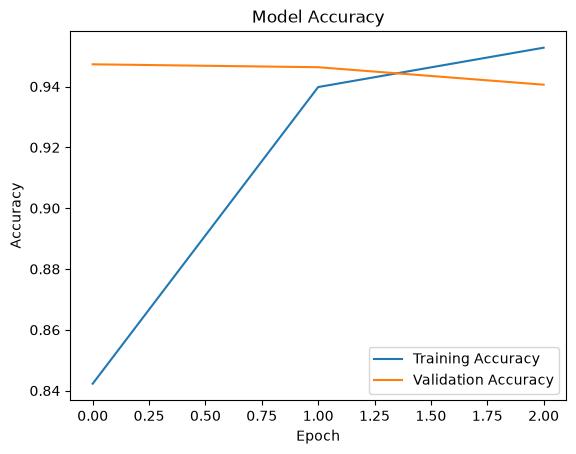

In [13]:
plt.plot(history.history["accuracy"],label= "Training Accuracy")
plt.plot(history.history["val_accuracy"],label = "Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Loss Plot

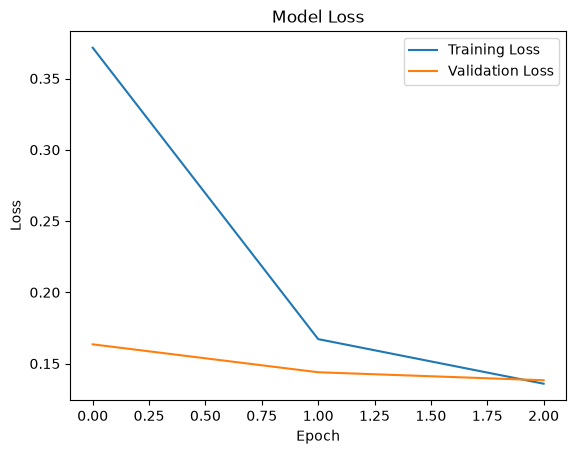

In [15]:
plt.plot(history.history["loss"], label = "Training Loss")
plt.plot(history.history["val_loss"],label = "Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Save Trained Model

In [17]:
model.save("../models/chest_xray_cnn_model.keras")
print("Model Saved Successfully")

Model Saved Successfully


In [18]:
loss , accuracy = model.evaluate(x_val , y_val)

print(f"Validation Loss : {loss : 4f}")
print(f"Validation Accuracy : {accuracy : 4f}")

33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 218ms/step - accuracy: 0.9406 - loss: 0.1383
Validation Loss :  0.138317
Validation Accuracy :  0.940613


### Make Predictions

In [19]:
predictions = model.predict(x_val)

print(predictions[:5])

33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step
[[0.95819116]
 [0.99997884]
 [0.9996299 ]
 [0.01572003]
 [0.9999997 ]]


In [21]:
predicted_class = (predictions > 0.5).astype(int)
print(predicted_class[:10])

[[1]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [1]]


### Compare with Actual labels


In [22]:
print("Predicted : " , predicted_class[:10].flatten())
print("Actual : ",y_val[:10])

Predicted :  [1 1 1 0 1 1 1 1 0 1]
Actual :  [1 1 1 0 1 1 1 1 0 1]


In [23]:
from sklearn.metrics import confusion_matrix , classification_report

### Create confusion matrix

In [24]:
cm = confusion_matrix(y_val , predicted_class)
print(cm)

[[262   6]
 [ 56 720]]


### Classification Report 

In [25]:
print(classification_report(y_val , predicted_class , target_names = ["Normal","Pneumonia"]))

              precision    recall  f1-score   support

      Normal       0.82      0.98      0.89       268
   Pneumonia       0.99      0.93      0.96       776

    accuracy                           0.94      1044
   macro avg       0.91      0.95      0.93      1044
weighted avg       0.95      0.94      0.94      1044



In [26]:
model.save("../models/chest_xray_cnn_models.keras")